
## **TRAINING**
```
# This is formatted as code
```



In [ ]:

import kagglehub
kagglehub.login()


Kaggle credentials set.
Kaggle credentials successfully validated.


In [ ]:
bigdata_bigdata_rooftop_path = kagglehub.dataset_download('bigdata/bigdata-rooftop')

print('Data source import complete.')

100%|██████████| 9.95G/9.95G [09:22<00:00, 19.0MB/s]

Extracting files...


Data source import complete.


In [ ]:
print(bigdata_bigdata_rooftop_path)

/root/.cache/kagglehub/datasets/bigdata404/bigdata-rooftop/versions/1


In [ ]:
import os

BASE_DIR = bigdata_bigdata_rooftop_path
IMAGE_DIR = os.path.join(BASE_DIR, 'image')
LABEL_DIR = os.path.join(BASE_DIR, 'labels')
TXT_PATH = os.path.join(BASE_DIR, 'train.txt')

OUTPUT_DIR = 'models'
os.makedirs(OUTPUT_DIR, exist_ok=True)


In [ ]:
print("Images:", os.listdir(IMAGE_DIR)[:5])
print("Labels:", os.listdir(LABEL_DIR)[:5])
print("TXT File:", TXT_PATH)


Images: ['output_15439.png', 'output_14783.png', 'output_10721.png', 'output_18332.png', 'output_18278.png']
Labels: ['output_15439.png', 'output_14783.png', 'output_10721.png', 'output_18332.png', 'output_18278.png']
TXT File: /root/.cache/kagglehub/datasets/bigdata404/bigdata-rooftop/versions/1/train.txt


In [ ]:
!pip install --trusted-host pypi.org --trusted-host pypi.python.org --trusted-host=files.pythonhosted.org rasterio opencv-python tensorflow keras



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 89.3 MB/s eta 0:00:00


In [1]:
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
import os



OUTPUT_DIR = 'models/rooftop_models_50epochs'
os.makedirs(OUTPUT_DIR, exist_ok=True)


AttributeError: module 'gast' has no attribute 'NodeTransformer'

In [2]:
import numpy as np
import cv2
import rasterio
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Conv2DTranspose
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
import os

ModuleNotFoundError: No module named 'rasterio'

In [3]:
# defining model
def build_model(height, width, channels, nclasses):
    inputs = Input(shape=(height, width, channels))

    c1 = Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
    p1 = MaxPooling2D((2,2))(c1)

    c2 = Conv2D(64, (3,3), activation='relu', padding='same')(p1)
    p2 = MaxPooling2D((2,2))(c2)

    c3 = Conv2D(128, (3,3), activation='relu', padding='same')(p2)

    u1 = Conv2DTranspose(64, (2,2), strides=(2,2), padding='same')(c3)
    u1 = Conv2D(64, (3,3), activation='relu', padding='same')(u1)

    u2 = Conv2DTranspose(32, (2,2), strides=(2,2), padding='same')(u1)
    u2 = Conv2D(32, (3,3), activation='relu', padding='same')(u2)

    outputs = Conv2D(nclasses, (1,1), activation='softmax')(u2)

    model = Model(inputs=[inputs], outputs=[outputs])
    return model


In [ ]:
# data generator
def data_generator(lines, batch_size, image_dir, label_dir):
    n = len(lines)
    i = 0
    while True:
        X = []
        Y = []
        for _ in range(batch_size):
            if i == 0:
                np.random.shuffle(lines)

            name = lines[i].strip().split(';')
            img_path = os.path.join(image_dir, name[0])
            label_path = os.path.join(label_dir, name[1])

            # Read Image
            img = rasterio.open(img_path)
            img = np.moveaxis(img.read()[0:3], 0, 2) / 255.0

            # Read Label
            label = cv2.imread(label_path, cv2.IMREAD_GRAYSCALE) / 255.0
            label = (label > 0.5).astype(np.uint8)

            seg_labels = np.zeros((512, 512, 2))
            seg_labels[:, :, 0] = (label == 0).astype(int)
            seg_labels[:, :, 1] = (label == 1).astype(int)

            X.append(img)
            Y.append(seg_labels)

            i = (i + 1) % n

        yield np.array(X), np.array(Y)


In [ ]:
# training setup
HEIGHT = 512
WIDTH = 512
NCLASSES = 2
BATCH_SIZE = 4
EPOCHS = 50

with open(TXT_PATH, "r") as f:
    lines = f.readlines()

np.random.shuffle(lines)
num_val = int(len(lines) * 0.1)
num_train = len(lines) - num_val


In [ ]:
model_instance = build_model(HEIGHT, WIDTH, 3, NCLASSES)
model_instance.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=1e-4),
    metrics=['accuracy']
)
#categorical or sparse check
print("\nLabel Format Example:", "(1,0) or (0,1)" if model_instance.loss == 'categorical_crossentropy' else "0 or 1")


Label Format Example: (1,0) or (0,1)


In [ ]:
# callback
checkpoint = ModelCheckpoint(
    os.path.join(OUTPUT_DIR, f'best_model_{EPOCHS}_epoch.h5'),
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    verbose=1,
    min_lr=1e-6
)



In [ ]:
# train the model
model_instance.fit(
    data_generator(lines[:num_train], BATCH_SIZE, IMAGE_DIR, LABEL_DIR),
    steps_per_epoch=max(1, num_train // BATCH_SIZE),
    validation_data=data_generator(lines[num_train:], BATCH_SIZE, IMAGE_DIR, LABEL_DIR),
    validation_steps=max(1, num_val // BATCH_SIZE),
    epochs=EPOCHS,
    callbacks=[checkpoint, reduce_lr],
    verbose=1
)
# Save final model
final_model_path = os.path.join(OUTPUT_DIR, f'final_model_{EPOCHS}_epoch.h5')
model_instance.save(final_model_path)

# Save/download best model (from checkpoint)
best_model_path = os.path.join(OUTPUT_DIR, f'best_model_{EPOCHS}_epoch.h5')
if os.path.exists(best_model_path):
    print(" Best model saved:", best_model_path)
else:
    print(" Best model not found or not updated.")


/usr/local/lib/python3.11/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(None, 512, 512, 3))
  warnings.warn(msg)


4452/4452 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.7501 - loss: 0.5006
Epoch 1: val_loss improved from inf to 0.42333, saving model to /content/drive/MyDrive/rooftop_models_50epochs/best_model_50_epoch.h5


4452/4452 ━━━━━━━━━━━━━━━━━━━━ 469s 103ms/step - accuracy: 0.7501 - loss: 0.5006 - val_accuracy: 0.8063 - val_loss: 0.4233 - learning_rate: 1.0000e-04
Epoch 2/50
4452/4452 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.8045 - loss: 0.4239
Epoch 2: val_loss improved from 0.42333 to 0.40857, saving model to /content/drive/MyDrive/rooftop_models_50epochs/best_model_50_epoch.h5


...

4452/4452 ━━━━━━━━━━━━━━━━━━━━ 400s 90ms/step - accuracy: 0.8506 - loss: 0.3444 - val_accuracy: 0.8537 - val_loss: 0.3394 - learning_rate: 1.0000e-04
Epoch 40/50
4452/4452 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.8494 - loss: 0.3467
Epoch 40: val_loss did not improve from 0.33938
4452/4452 ━━━━━━━━━━━━━━━━━━━━ 396s 89ms/step - accuracy: 0.8494 - loss: 0.3467 - val_accuracy: 0.8496 - val_loss: 0.3476 - learning_rate: 1.0000e-04
Epoch 41/50
4452/4452 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.8499 - loss: 0.3458
Epoch 41: val_loss did not improve from 0.33938
4452/4452 ━━━━━━━━━━━━━━━━━━━━ 400s 90ms/step - accuracy: 0.8499 - loss: 0.3458 - val_accuracy: 0.8533 - val_loss: 0.3416 - learning_rate: 1.0000e-04
Epoch 42/50
4452/4452 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.8513 - loss: 0.3432
Epoch 42: val_loss did not improve from 0.33938
4452/4452 ━━━━━━━━━━━━━━━━━━━━ 401s 90ms/step - accuracy: 0.8513 - loss: 0.3432 - val_accuracy: 0.8532 - val_loss: 0.3408 - learning_rat

4452/4452 ━━━━━━━━━━━━━━━━━━━━ 402s 90ms/step - accuracy: 0.8524 - loss: 0.3408 - val_accuracy: 0.8544 - val_loss: 0.3385 - learning_rate: 5.0000e-05
Epoch 46/50
4452/4452 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.8533 - loss: 0.3389
Epoch 46: val_loss improved from 0.33850 to 0.33704, saving model to /content/drive/MyDrive/rooftop_models_50epochs/best_model_50_epoch.h5


4452/4452 ━━━━━━━━━━━━━━━━━━━━ 403s 91ms/step - accuracy: 0.8533 - loss: 0.3389 - val_accuracy: 0.8549 - val_loss: 0.3370 - learning_rate: 5.0000e-05
Epoch 47/50
4452/4452 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.8532 - loss: 0.3391
Epoch 47: val_loss did not improve from 0.33704
4452/4452 ━━━━━━━━━━━━━━━━━━━━ 400s 90ms/step - accuracy: 0.8532 - loss: 0.3391 - val_accuracy: 0.8528 - val_loss: 0.3414 - learning_rate: 5.0000e-05
Epoch 48/50
4452/4452 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.8534 - loss: 0.3389
Epoch 48: val_loss improved from 0.33704 to 0.33655, saving model to /content/drive/MyDrive/rooftop_models_50epochs/best_model_50_epoch.h5


4452/4452 ━━━━━━━━━━━━━━━━━━━━ 393s 88ms/step - accuracy: 0.8534 - loss: 0.3389 - val_accuracy: 0.8555 - val_loss: 0.3366 - learning_rate: 5.0000e-05
Epoch 49/50
4452/4452 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.8533 - loss: 0.3390
Epoch 49: val_loss did not improve from 0.33655
4452/4452 ━━━━━━━━━━━━━━━━━━━━ 392s 88ms/step - accuracy: 0.8533 - loss: 0.3390 - val_accuracy: 0.8549 - val_loss: 0.3372 - learning_rate: 5.0000e-05
Epoch 50/50
4452/4452 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.8540 - loss: 0.3381
Epoch 50: val_loss did not improve from 0.33655
4452/4452 ━━━━━━━━━━━━━━━━━━━━ 392s 88ms/step - accuracy: 0.8540 - loss: 0.3381 - val_accuracy: 0.8547 - val_loss: 0.3375 - learning_rate: 5.0000e-05


✅ Best model saved: /content/drive/MyDrive/rooftop_models_50epochs/best_model_50_epoch.h5


# **Testing Part**

In [ ]:
# Open train.txt to get image names
with open(TXT_PATH, 'r') as f:
    lines = f.readlines()

# Pick any image index — change 0 to any number
index = 0
name = lines[index].strip().split(';')

img_path = os.path.join(IMAGE_DIR, name[0])
label_path = os.path.join(LABEL_DIR, name[1])

print("Testing image:", name[0])


Testing image: output_1.png


In [ ]:
# Read Image
img = rasterio.open(img_path)
img = np.moveaxis(img.read()[0:3], 0, 2) / 255.0
input_img = np.expand_dims(img, axis=0)

# Read Label for comparison
label = cv2.imread(label_path, cv2.IMREAD_GRAYSCALE) / 255.0
label = (label > 0.5).astype(np.uint8)


/usr/local/lib/python3.11/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


In [ ]:
prediction = model_instance.predict(input_img)
pred_mask = np.argmax(prediction[0], axis=-1)


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 512, 512, 3))
  warnings.warn(msg)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 793ms/step


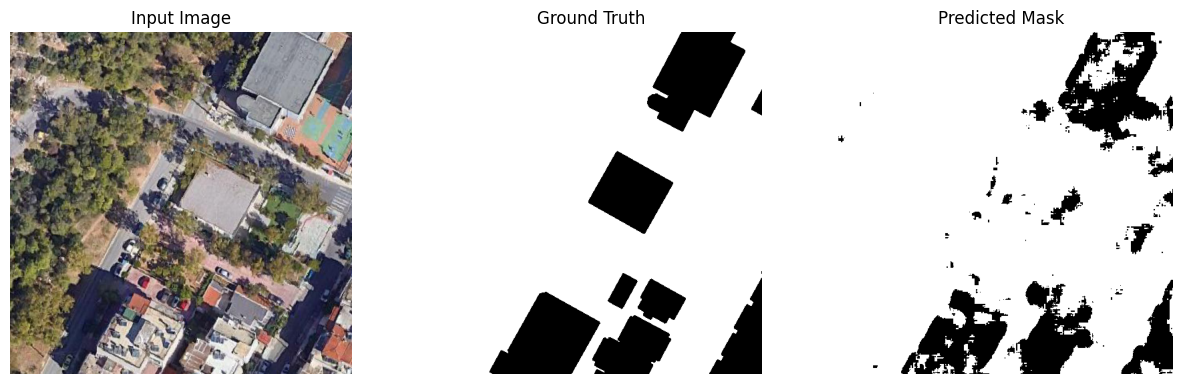

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img)
plt.title('Input Image')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(label, cmap='gray')
plt.title('Ground Truth')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(pred_mask, cmap='gray')
plt.title('Predicted Mask')
plt.axis('off')

plt.show()
